In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
df = pd.read_csv('/content/drive/My Drive/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [4]:
df = df.drop(columns=['agent', 'company'])

In [5]:
most_frequent_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(most_frequent_country)

In [6]:
df['children'] = df['children'].fillna(0)

In [7]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [8]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list              

In [9]:
import calendar
from datetime import datetime

In [10]:
seasons = {
    'Summer': ['February', 'March', 'April', 'May'],
    'Monsoon': ['June', 'July', 'August', 'September'],
    'Winter': ['October', 'November', 'December', 'January', 'February']
}
def month_to_season(month):
    for season, months in seasons.items():
        if month in months:
            return season

df['season'] = df['arrival_date_month'].apply(month_to_season)

In [11]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,Monsoon
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,Monsoon
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,Monsoon
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,Monsoon
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,Monsoon


In [12]:
# Adding total staying days in hotels
df['total_stay'] = df['stays_in_weekend_nights']+df['stays_in_week_nights']

In [13]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,season,total_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,Monsoon,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,Monsoon,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,Monsoon,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,Monsoon,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,Monsoon,2


In [14]:
df = df[df['adults'] != 0]
(df['adults'] == 0).any()

False

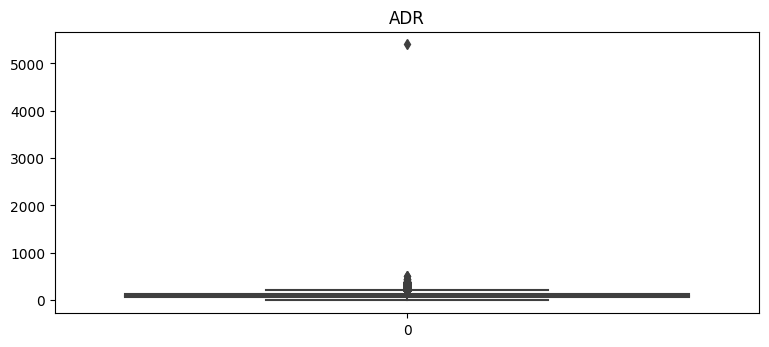

In [15]:
# Checking for outliers in ADR column

plt.figure(figsize=(20,30))
plt.subplot(7, 2, 1)
sns.boxplot(df['adr'])
plt.title('ADR')
plt.show()

In [33]:
# Removing outliers
df.drop(df[df['adr'] > 5000].index, inplace = True)

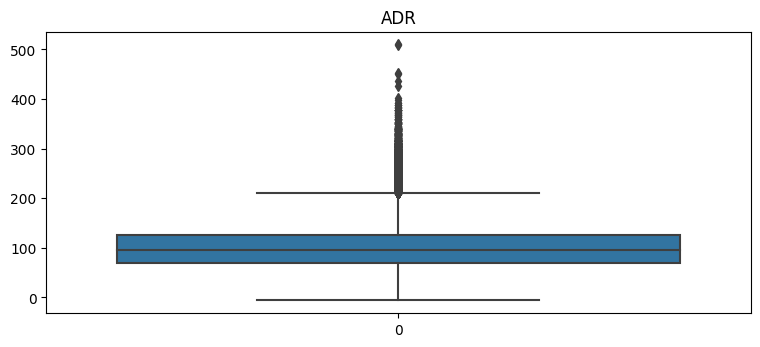

In [34]:
plt.figure(figsize=(20,30))
plt.subplot(7, 2, 1)
sns.boxplot(df['adr'])
plt.title('ADR')
plt.show()

In [18]:
df1 = df.copy()

In [19]:
encoding = {"arrival_date_month":     {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5,
                                       "June": 6, "July": 7, "August": 8, "September": 9,
                                       "October": 10, "November": 11, "December": 12}}
df = df.replace(encoding)

In [20]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,season,total_stay
0,Resort Hotel,0,342,2015,7,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,Monsoon,0
1,Resort Hotel,0,737,2015,7,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,Monsoon,0
2,Resort Hotel,0,7,2015,7,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,Monsoon,1
3,Resort Hotel,0,13,2015,7,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,Monsoon,1
4,Resort Hotel,0,14,2015,7,27,1,0,2,2,...,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,Monsoon,2


In [21]:
df1['adr'].mean()

101.9635496613047

In [22]:
df1['adr'].median()

95.0

In [23]:
df1['adr'].mode()[0]

62.0

In [24]:
df1['adr'].std() # standard deviation

48.05415394689186

In [25]:
df1['adr'].var() # variance

2309.2017115515823

In [26]:
df1['adr'].skew()

1.0313813906285494

In [27]:
df1['adr'].kurtosis()

2.1451330986662906

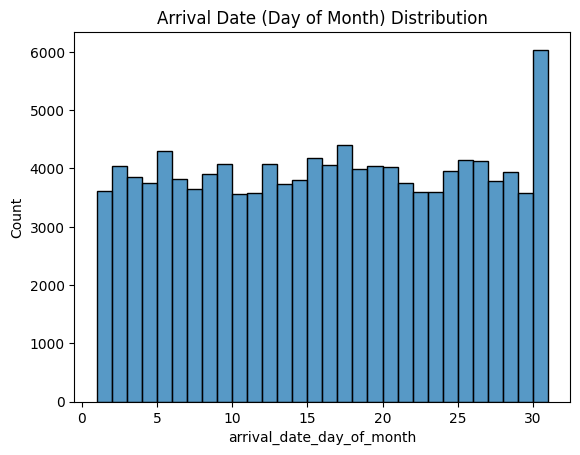

In [28]:
# Arrival Date (Day of Month)
sns.histplot(df1['arrival_date_day_of_month'], kde=False, bins=30)
plt.title('Arrival Date (Day of Month) Distribution')
plt.show()

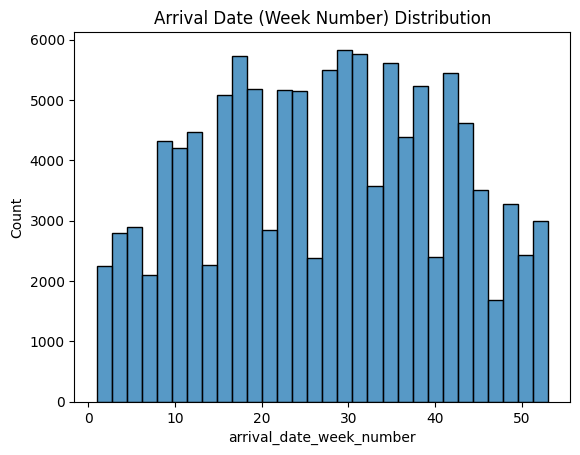

In [29]:
# Arrival Date (Week Number)
sns.histplot(df1['arrival_date_week_number'], kde=False, bins=30)
plt.title('Arrival Date (Week Number) Distribution')
plt.show()

<Axes: >

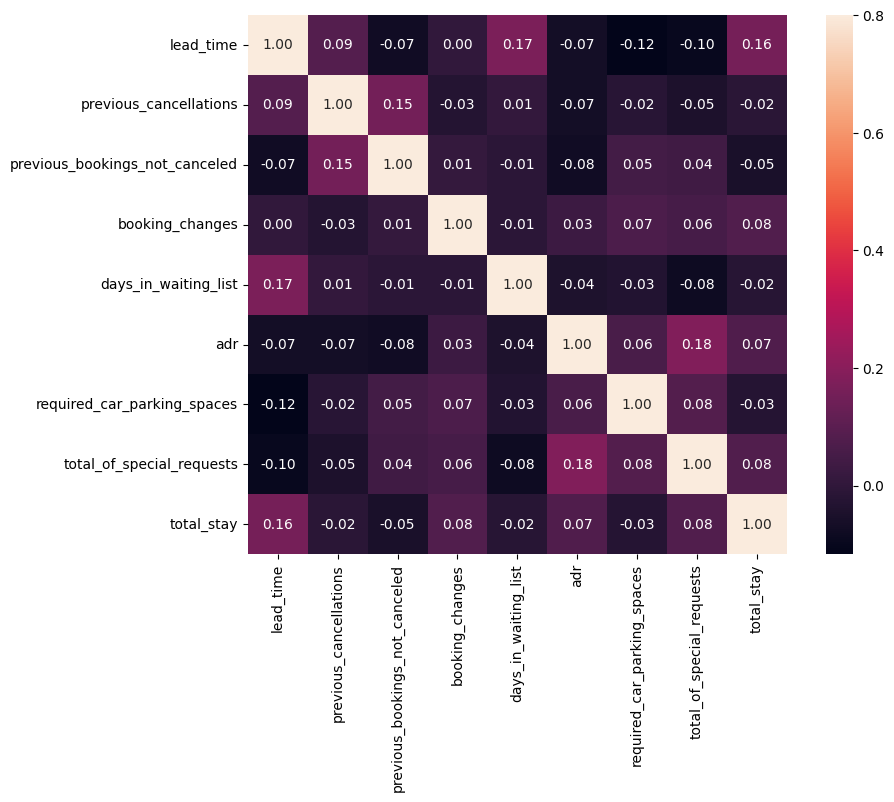

In [30]:
df2 = df1[['lead_time','previous_cancellations','previous_bookings_not_canceled','booking_changes',
           'days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests','total_stay']]
#correlation matrix
corrmat = df2.corr()
f, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corrmat, annot = True, fmt='.2f', annot_kws={'size': 10},  vmax=.8, square=True)

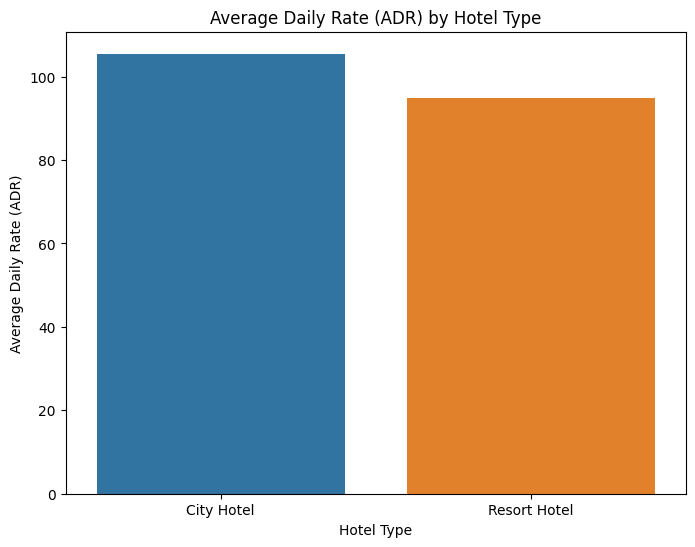

In [31]:
hotel_adr_mean = df.groupby('hotel')['adr'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='hotel', y='adr', data=hotel_adr_mean)
plt.title('Average Daily Rate (ADR) by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.show()

In [32]:
import plotly.express as px
adr_vs_hotel = px.box(df, x="hotel", y="adr",color="hotel")
adr_vs_hotel.show()

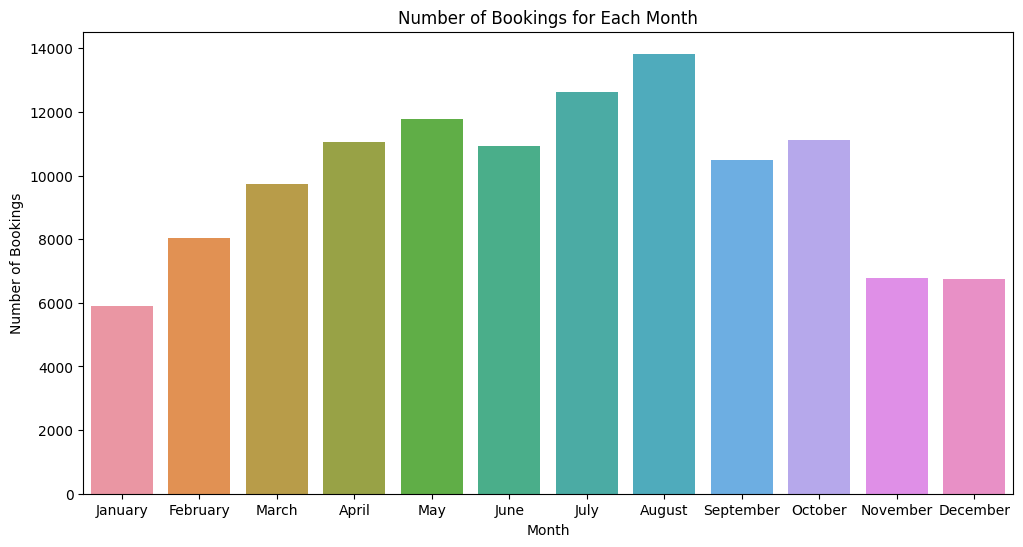

In [37]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
                'August', 'September', 'October', 'November', 'December']

# Plot the number of bookings for each month
plt.figure(figsize=(12,6))
sns.countplot(x='arrival_date_month', data=df1, order=months_order)
plt.title('Number of Bookings for Each Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.show()

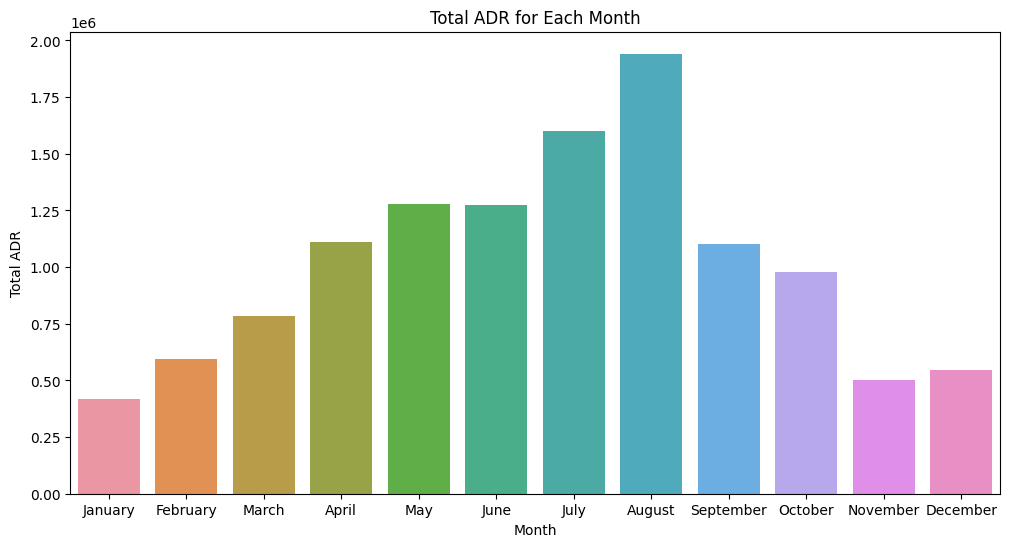

In [42]:
# Calculate the total ADR for each month
total_adr_month = df1.groupby('arrival_date_month')['adr'].sum().reindex(months_order)

# Create a bar plot for total ADR in each month
plt.figure(figsize=(12,6))
sns.barplot(x=total_adr_month.index, y=total_adr_month.values)
plt.title('Total ADR for Each Month')
plt.xlabel('Month')
plt.ylabel('Total ADR')
plt.show()

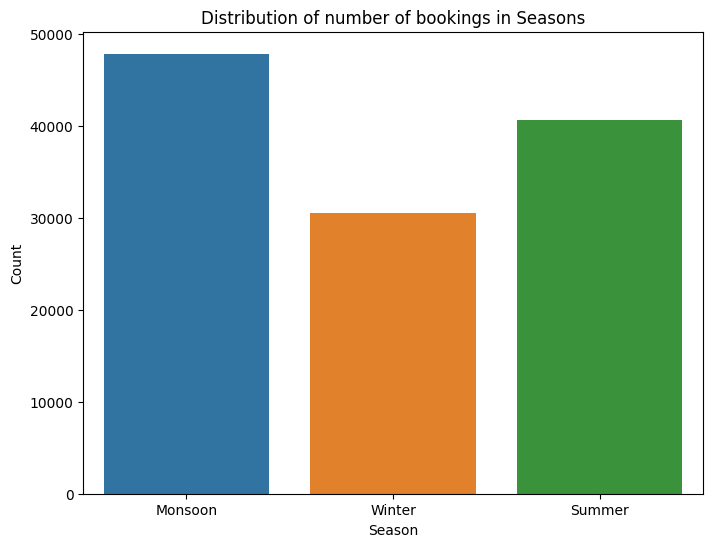

In [41]:
# Plot distribution of number of bookings in season
plt.figure(figsize=(8,6))
sns.countplot(x='season', data=df1)
plt.title('Distribution of number of bookings in Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()